
Simulation completed.
   SNR_dB  CSI_Error_Variance Allocation   a1   a2  Sum_Rate  Outage_User1  \
0       0                 0.0      Fixed  0.8  0.2  0.860849       0.80968   
1       0                 0.0     Robust  0.8  0.2  0.861016       0.80982   
2       5                 0.0      Fixed  0.8  0.2  1.717609       0.40930   
3       5                 0.0     Robust  0.8  0.2  1.714931       0.40963   
4      10                 0.0      Fixed  0.8  0.2  2.908288       0.15266   

   Outage_User2  
0       0.99333  
1       0.99313  
2       0.79430  
3       0.79398  
4       0.39189  


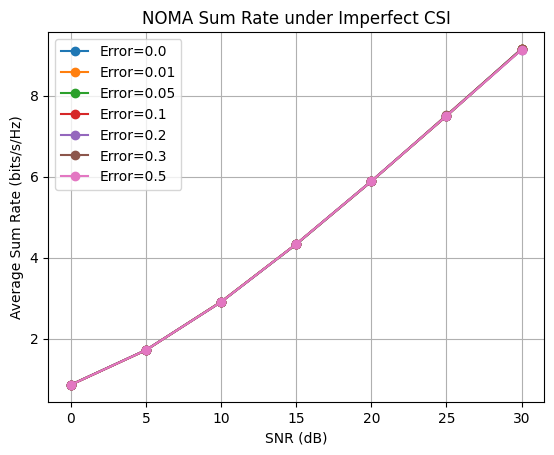

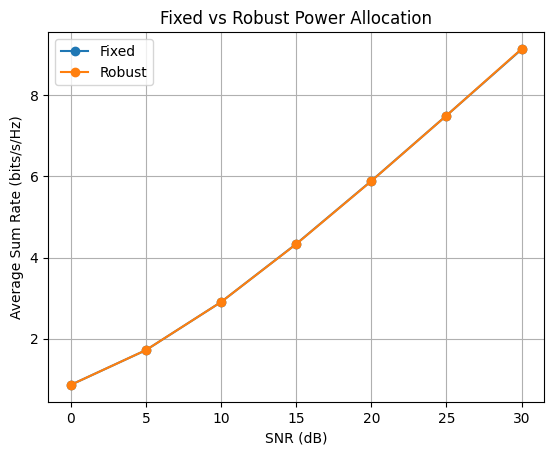

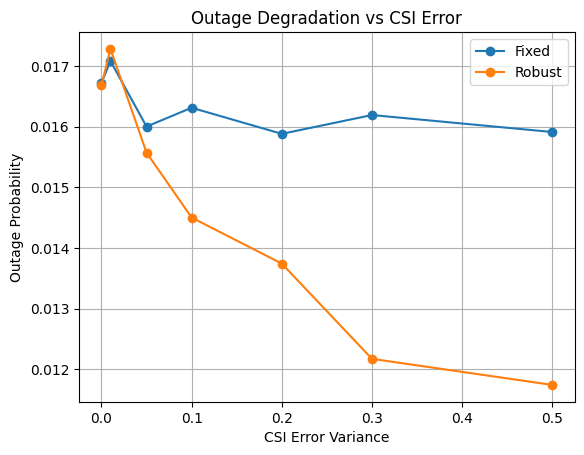

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# NOMA UNDER IMPERFECT CSI
# ============================================================

# Simulation parameters
NUM_SAMPLES = 100000

SNR_DB = np.arange(0, 31, 5)

CSI_ERRORS = [0.0, 0.01, 0.05, 0.10, 0.20, 0.30, 0.50]

TARGET_RATE = 1.0

# Fixed NOMA power allocation
FIXED_A1 = 0.80
FIXED_A2 = 0.20

# Noise power
NOISE_POWER = 1.0

# ============================================================
# Channel generation
# ============================================================

def generate_channels(num_samples, error_variance):

    # Rayleigh fading
    h1_real = np.random.randn(num_samples)
    h1_imag = np.random.randn(num_samples)

    h2_real = np.random.randn(num_samples)
    h2_imag = np.random.randn(num_samples)

    h1 = (h1_real + 1j * h1_imag) / np.sqrt(2)
    h2 = (h2_real + 1j * h2_imag) / np.sqrt(2)

    # Channel estimation error
    error1 = (
        np.random.randn(num_samples)
        + 1j * np.random.randn(num_samples)
    ) * np.sqrt(error_variance / 2)

    error2 = (
        np.random.randn(num_samples)
        + 1j * np.random.randn(num_samples)
    ) * np.sqrt(error_variance / 2)

    # Estimated CSI
    h1_est = h1 + error1
    h2_est = h2 + error2

    return h1, h2, h1_est, h2_est


# ============================================================
# NOMA simulation
# ============================================================

def simulate_noma(snr_db, error_variance, a1, a2):

    P = 10 ** (snr_db / 10)

    h1, h2, h1_est, h2_est = generate_channels(
        NUM_SAMPLES,
        error_variance
    )

    # Actual channel gains
    g1 = np.abs(h1) ** 2
    g2 = np.abs(h2) ** 2

    # SINR of weak user
    sinr1 = (
        P * a1 * g1 /
        (P * a2 * g1 + NOISE_POWER)
    )

    # SINR of strong user
    sinr2 = (
        P * a2 * g2 /
        NOISE_POWER
    )

    # Achievable rates
    r1 = np.log2(1 + sinr1)
    r2 = np.log2(1 + sinr2)

    # Sum rate
    sum_rate = np.mean(r1 + r2)

    # Outage probability
    outage1 = np.mean(r1 < TARGET_RATE)
    outage2 = np.mean(r2 < TARGET_RATE)

    return sum_rate, outage1, outage2


# ============================================================
# Robust power allocation
# ============================================================

def robust_allocation(error_variance):

    # Simple robustness strategy
    if error_variance <= 0.01:
        a1 = 0.80

    elif error_variance <= 0.05:
        a1 = 0.82

    elif error_variance <= 0.10:
        a1 = 0.84

    elif error_variance <= 0.20:
        a1 = 0.87

    elif error_variance <= 0.30:
        a1 = 0.90

    else:
        a1 = 0.92

    a2 = 1 - a1

    return a1, a2


# ============================================================
# Main simulation
# ============================================================

results = []

for error in CSI_ERRORS:

    robust_a1, robust_a2 = robust_allocation(error)

    for snr in SNR_DB:

        # Fixed allocation
        fixed_sum, fixed_out1, fixed_out2 = simulate_noma(
            snr,
            error,
            FIXED_A1,
            FIXED_A2
        )

        # Robust allocation
        robust_sum, robust_out1, robust_out2 = simulate_noma(
            snr,
            error,
            robust_a1,
            robust_a2
        )

        results.append([
            snr,
            error,
            "Fixed",
            FIXED_A1,
            FIXED_A2,
            fixed_sum,
            fixed_out1,
            fixed_out2
        ])

        results.append([
            snr,
            error,
            "Robust",
            robust_a1,
            robust_a2,
            robust_sum,
            robust_out1,
            robust_out2
        ])


# ============================================================
# Save results
# ============================================================

columns = [
    "SNR_dB",
    "CSI_Error_Variance",
    "Allocation",
    "a1",
    "a2",
    "Sum_Rate",
    "Outage_User1",
    "Outage_User2"
]

df = pd.DataFrame(results, columns=columns)

df.to_csv("results.csv", index=False)

print("\nSimulation completed.")
print(df.head())


# ============================================================
# Plot 1: Sum rate vs SNR
# ============================================================

plt.figure()

for error in CSI_ERRORS:

    subset = df[
        (df["CSI_Error_Variance"] == error) &
        (df["Allocation"] == "Fixed")
    ]

    plt.plot(
        subset["SNR_dB"],
        subset["Sum_Rate"],
        marker="o",
        label=f"Error={error}"
    )

plt.xlabel("SNR (dB)")
plt.ylabel("Average Sum Rate (bits/s/Hz)")
plt.title("NOMA Sum Rate under Imperfect CSI")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Plot 2: Fixed vs Robust
# ============================================================

selected_error = 0.20

plt.figure()

for allocation in ["Fixed", "Robust"]:

    subset = df[
        (df["CSI_Error_Variance"] == selected_error) &
        (df["Allocation"] == allocation)
    ]

    plt.plot(
        subset["SNR_dB"],
        subset["Sum_Rate"],
        marker="o",
        label=allocation
    )

plt.xlabel("SNR (dB)")
plt.ylabel("Average Sum Rate (bits/s/Hz)")
plt.title("Fixed vs Robust Power Allocation")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Plot 3: Outage vs CSI error
# ============================================================

selected_snr = 20

plt.figure()

for allocation in ["Fixed", "Robust"]:

    values = []

    for error in CSI_ERRORS:

        subset = df[
            (df["CSI_Error_Variance"] == error) &
            (df["SNR_dB"] == selected_snr) &
            (df["Allocation"] == allocation)
        ]

        values.append(subset["Outage_User1"].values[0])

    plt.plot(
        CSI_ERRORS,
        values,
        marker="o",
        label=allocation
    )

plt.xlabel("CSI Error Variance")
plt.ylabel("Outage Probability")
plt.title("Outage Degradation vs CSI Error")
plt.grid(True)
plt.legend()
plt.show()